Name - Shrushti Changedia

# Topic:- Dominos Pizza Ordering Pattern Forecasting

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [29]:
df = pd.read_csv(r'C:\Users\Shrushti\Downloads\Pizza_Sale.csv')

In [30]:
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [31]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48613.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821494
std,14035.529381,6180.119770,0.143077,3.621789,4.437520
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48604 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48613 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48597 non-null  object 
 10  pizza_ingredients  48607 non-null  object 
 11  pizza_name         48613 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


# Cleaning Data

In [33]:
#To check missing values
df.isnull().sum()

pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64

In [34]:
df = pd.read_csv(r'C:\Users\Shrushti\Downloads\Pizza_Sale.csv')

In [35]:
#fill numerical missing values with mean (numerical values)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['order_date'] = df['order_date'].fillna(df['order_date'].mean())
df['total_price'] = pd.to_datetime(df['total_price'], errors='coerce')
df['total_price'] = df['total_price'].fillna(df['total_price'].mean())
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01 00:00:00.000000000,11:38:36,13.25,1970-01-01 00:00:00.000000013,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01 00:00:00.000000000,11:57:40,16.00,1970-01-01 00:00:00.000000016,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01 00:00:00.000000000,11:57:40,18.50,1970-01-01 00:00:00.000000018,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01 00:00:00.000000000,11:57:40,20.75,1970-01-01 00:00:00.000000020,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01 00:00:00.000000000,11:57:40,16.00,1970-01-01 00:00:00.000000016,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-06-18 23:49:55.680808960,21:23:10,16.75,1970-01-01 00:00:00.000000016,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,2015-06-18 23:49:55.680808960,21:23:10,17.95,1970-01-01 00:00:00.000000017,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,2015-06-18 23:49:55.680808960,21:23:10,12.00,1970-01-01 00:00:00.000000012,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,2015-06-18 23:49:55.680808960,22:09:54,20.25,1970-01-01 00:00:00.000000020,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [36]:
#fill categorical missing values with mode (categorical values)
for col in ['Pizza Category', 'Pizza Ingredients', 'Pizza Name', 'Month', 'Weekday']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01 00:00:00.000000000,11:38:36,13.25,1970-01-01 00:00:00.000000013,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01 00:00:00.000000000,11:57:40,16.00,1970-01-01 00:00:00.000000016,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01 00:00:00.000000000,11:57:40,18.50,1970-01-01 00:00:00.000000018,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01 00:00:00.000000000,11:57:40,20.75,1970-01-01 00:00:00.000000020,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01 00:00:00.000000000,11:57:40,16.00,1970-01-01 00:00:00.000000016,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-06-18 23:49:55.680808960,21:23:10,16.75,1970-01-01 00:00:00.000000016,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,2015-06-18 23:49:55.680808960,21:23:10,17.95,1970-01-01 00:00:00.000000017,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,2015-06-18 23:49:55.680808960,21:23:10,12.00,1970-01-01 00:00:00.000000012,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,2015-06-18 23:49:55.680808960,22:09:54,20.25,1970-01-01 00:00:00.000000020,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [37]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
48615    False
48616    False
48617    False
48618    False
48619    False
Length: 48620, dtype: bool

In [38]:
df.dtypes

pizza_id                      int64
order_id                      int64
pizza_name_id                object
quantity                      int64
order_date           datetime64[ns]
order_time                   object
unit_price                  float64
total_price          datetime64[ns]
pizza_size                   object
pizza_category               object
pizza_ingredients            object
pizza_name                   object
dtype: object

In [39]:
# Changing datatype of OrderTime from object to datetime
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S', errors='coerce')
print(df['order_time'])

0       1900-01-01 11:38:36
1       1900-01-01 11:57:40
2       1900-01-01 11:57:40
3       1900-01-01 11:57:40
4       1900-01-01 11:57:40
                ...        
48615   1900-01-01 21:23:10
48616   1900-01-01 21:23:10
48617   1900-01-01 21:23:10
48618   1900-01-01 22:09:54
48619   1900-01-01 23:02:05
Name: order_time, Length: 48620, dtype: datetime64[ns]


In [40]:
if 'total' in df.columns[0].lower():
    total_col = df.columns[0]
elif 'sales' in df.columns[0].lower():
    total_col = df.columns[0]
else:
    total_col = 'Total'  

print("Basic Stats for Sales:")
print(df.describe())

Basic Stats for Sales:
           pizza_id      order_id      quantity  \
count  48620.000000  48620.000000  48620.000000   
mean   24310.500000  10701.479761      1.019622   
min        1.000000      1.000000      1.000000   
25%    12155.750000   5337.000000      1.000000   
50%    24310.500000  10682.500000      1.000000   
75%    36465.250000  16100.000000      1.000000   
max    48620.000000  21350.000000      4.000000   
std    14035.529381   6180.119770      0.143077   

                          order_date                     order_time  \
count                          48620                          48620   
mean   2015-06-18 23:49:55.680808960  1900-01-01 16:24:51.322151424   
min              2015-01-01 00:00:00            1900-01-01 09:52:21   
25%    2015-06-18 23:49:55.680808960            1900-01-01 13:24:46   
50%    2015-06-18 23:49:55.680808960            1900-01-01 16:33:33   
75%    2015-06-18 23:49:55.680808960            1900-01-01 18:55:19   
max              201

In [41]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

# Key Insights from Data

In [43]:
df = pd.read_csv(r'C:\Users\Shrushti\Downloads\Pizza_Sale.csv')

#Total Revenue
df['total_price'].sum()   

np.float64(817743.3)

In [44]:
#Average order value
df['total_price'].mean()      

np.float64(16.821494250509122)

In [46]:
#Total Unique orders
df['order_id'].nunique()      

21350

In [45]:
# Total unique pizza types
df['pizza_name'].nunique()    

32

# Domino's Total Sales over Time

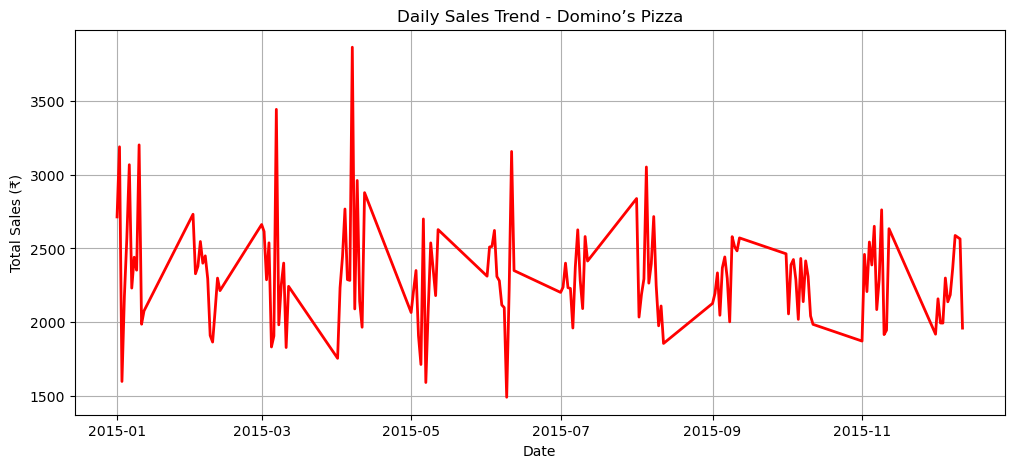

In [73]:
date_col = 'order_date'          
sales_col = 'total_price'        

# Convert date column to datetime
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Group and plot
daily_sales = df.groupby(df[date_col].dt.date)[sales_col].sum().reset_index()
daily_sales.columns = ['Date', 'TotalSales']

plt.figure(figsize=(12,5))
plt.plot(daily_sales['Date'], daily_sales['TotalSales'], color='red', linewidth=2)
plt.title("Daily Sales Trend - Domino’s Pizza")
plt.xlabel("Date")
plt.ylabel("Total Sales (₹)")
plt.grid(True)
plt.show()


# Interpretation 

The daily sales trend graph shows how Domino’s total sales fluctuate over time. The red line highlights the variations in daily revenue, helping identify both high and low-performing days.This visualization helps Domino’s understand sales patterns, plan inventory, and manage staff effectively. Consistent peaks on certain days (like weekends) may reflect higher customer activity, guiding marketing and promotional strategies.

# Domino's Revenue by Pizza Size

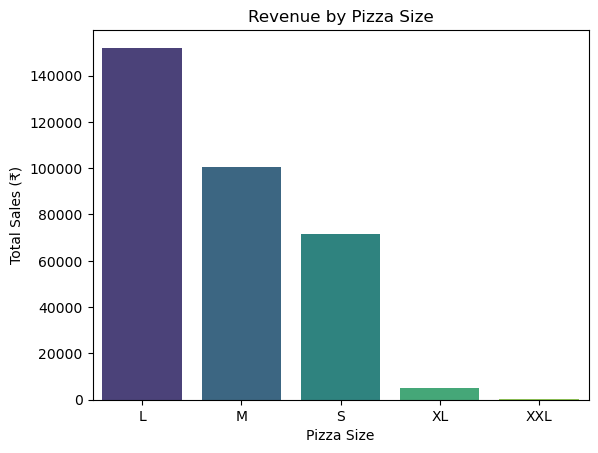

In [79]:
# Group data by pizza size and calculate total sales
size_sales = df.groupby('pizza_size')['total_price'].sum().sort_values(ascending=False)


sns.barplot(x=size_sales.index,
            y=size_sales.values,
            hue=size_sales.index,  
            legend=False,
            palette='viridis')

plt.title("Revenue by Pizza Size")
plt.xlabel("Pizza Size")
plt.ylabel("Total Sales (₹)")
plt.show()

# Interpretation

From the plot, it is evident that medium (M) and large (L) pizzas generate the highest revenue, indicating that most customers prefer these sizes. Small (S) pizzas contribute moderately to sales, while extra-large (XL) and extra-extra-large (XXL) pizzas have minimal demand.
This pattern suggests that Domino’s core revenue comes from regular-sized pizzas and promotional efforts can focus on these popular sizes to maximize sales.

# Top 10 Best - Selling Pizzas

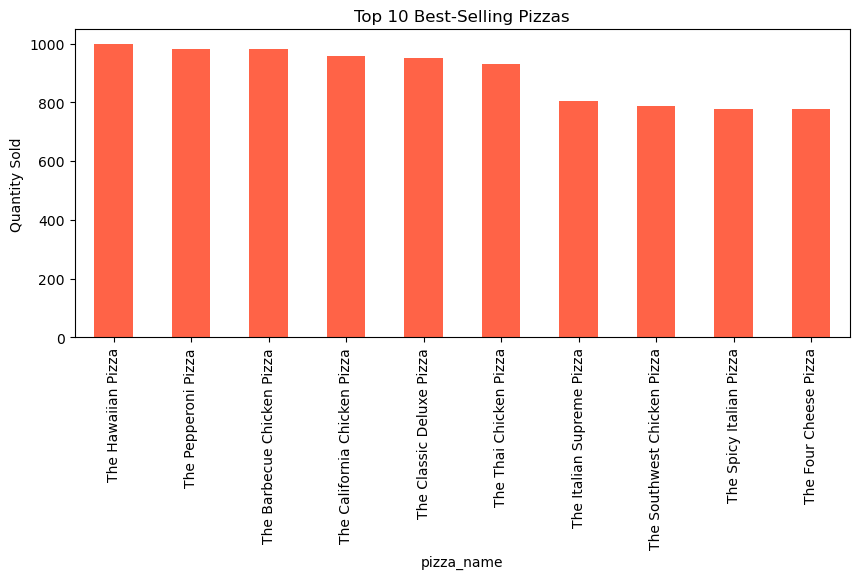

In [71]:
top_pizzas = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(10)
top_pizzas.plot(kind='bar', figsize=(10,4), color='tomato')
plt.title("Top 10 Best-Selling Pizzas")
plt.ylabel("Quantity Sold")
plt.show()

# Interpretation

The Hawaiian Pizza leads as the most popular choice among customers, closely followed by The Pepperoni Pizza and The Barbecue Chicken Pizza. These top-selling pizzas are primarily classic or chicken-based varieties, indicating a strong customer preference for familiar and flavorful options. Meanwhile, pizzas like The Spicy Italian Pizza and The Four Cheese Pizza rank slightly lower, suggesting niche or limited appeal.
This insight highlights which pizza types drive the most sales and can help Domino’s focus its marketing, promotions, and inventory planning on these high-performing products.

# Monthly Sales

<Axes: xlabel='Month'>

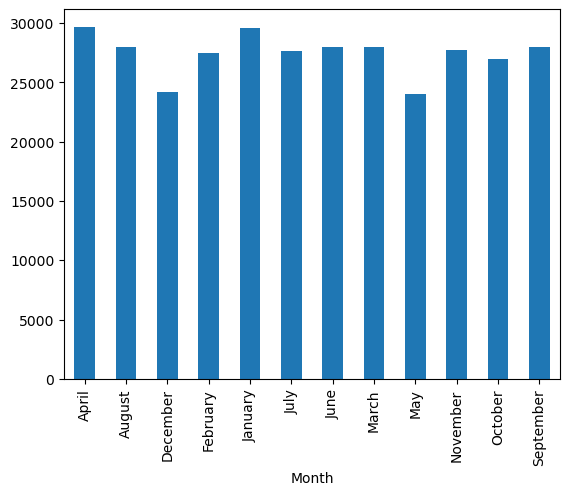

In [70]:
df['Month'] = df['order_date'].dt.month_name()
df.groupby('Month')['total_price'].sum().plot(kind='bar')


# Interpretation

It shows that April and January recorded the highest sales, indicating strong customer demand during these months- possibly due to holidays, promotions, or seasonal preferences. Conversely, May and December show relatively lower sales, suggesting slower business activity or fewer orders during those periods. Overall, sales remain fairly consistent across most months, reflecting steady customer demand for pizzas year-round, with only mild fluctuations.

# Weekly Revenue Of Dominos

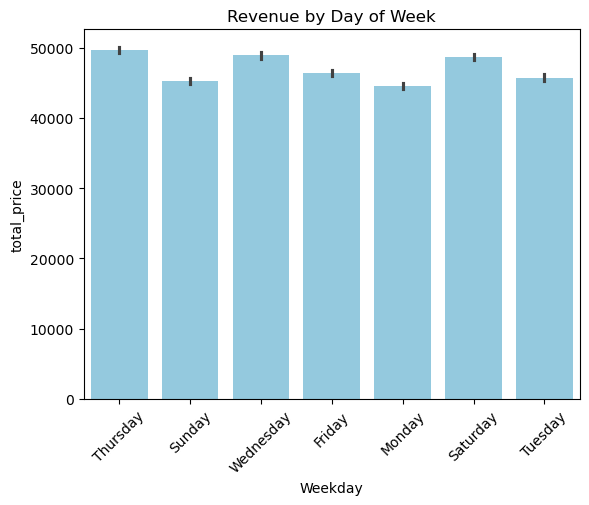

In [69]:
df['Weekday'] = df['order_date'].dt.day_name()
sns.barplot(x='Weekday', y='total_price', data=df, estimator=sum, color='skyblue')
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
plt.show()

# Interpretation

This reveals that Thursday, Wednesday, and Saturday have the highest revenues, suggesting stronger sales activity toward the mid and end of the week, possibly due to people dining out more or ordering pizzas for social gatherings. In contrast, Sunday and Friday show relatively lower revenues, indicating a slight dip during weekends.

# Price v/s Quantity Ordered

Text(0.5, 1.0, 'Price vs Quantity Ordered')

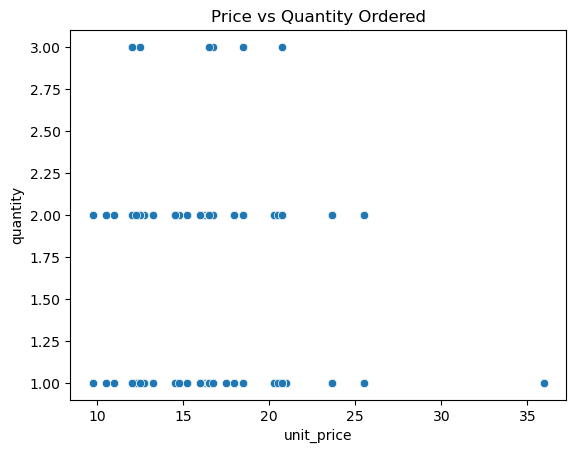

In [68]:
sns.scatterplot(x='unit_price', y='quantity', data=df)
plt.title("Price vs Quantity Ordered")


# Interpretation

The scatter plot shows the relationship between unit price and quantity ordered. The data points indicate that most pizzas are sold in small quantities (1–3 units) regardless of price. There is no clear correlation between price and quantity — both low and high-priced pizzas tend to be ordered in similar small quantities. This suggests that customers are likely purchasing pizzas based on preferences or taste rather than price sensitivity

# Forecasting Pizza Sales (using moving average)

In [75]:
# Ensure order_date is in datetime format
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Convert total_price to numeric, force invalid entries to NaN
df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')

# Drop rows where total_price or order_date is missing
df = df.dropna(subset=['order_date', 'total_price'])

# Group by date to get daily total sales
daily_sales = df.groupby('order_date')['total_price'].sum().reset_index()

# Sort by date
daily_sales = daily_sales.sort_values('order_date')


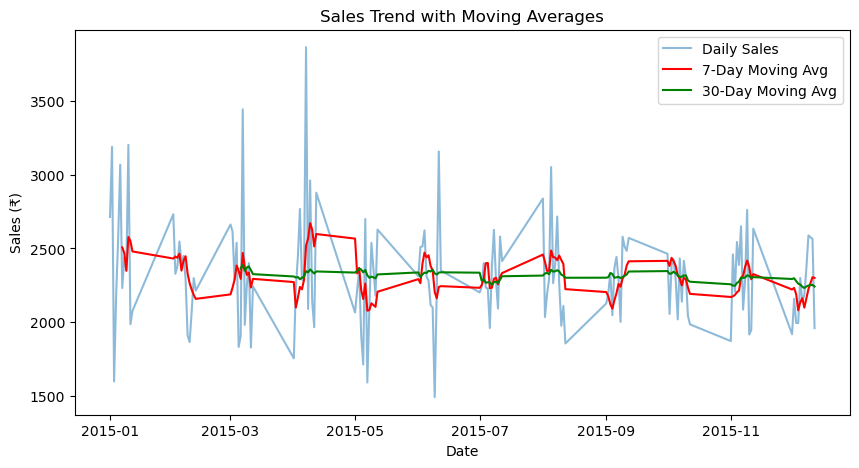

In [76]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Group by order_date to get total sales per day
daily_sales = df.groupby('order_date')['total_price'].sum().reset_index()
daily_sales = daily_sales.sort_values('order_date')

#Compute Moving Averages (7-day and 30-day)
daily_sales['MA7'] = daily_sales['total_price'].rolling(window=7).mean()
daily_sales['MA30'] = daily_sales['total_price'].rolling(window=30).mean()

plt.figure(figsize=(10,5))
plt.plot(daily_sales['order_date'], daily_sales['total_price'], label='Daily Sales', alpha=0.5)
plt.plot(daily_sales['order_date'], daily_sales['MA7'], label='7-Day Moving Avg', color='red')
plt.plot(daily_sales['order_date'], daily_sales['MA30'], label='30-Day Moving Avg', color='green')
plt.title("Sales Trend with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales (₹)")
plt.legend()
plt.show()

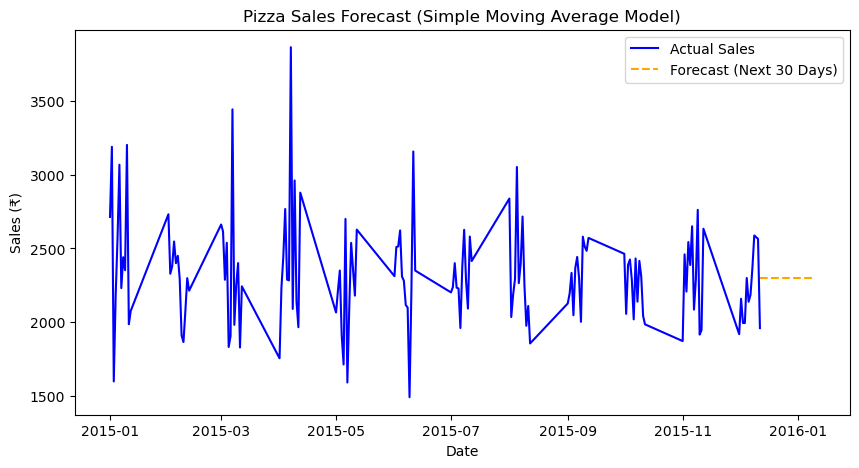

In [77]:
#Simple Forecast (based on recent moving average)
last_date = daily_sales['order_date'].max()
future_dates = pd.date_range(start=last_date, periods=30, freq='D')

# Forecast = mean of last 7 days
recent_avg = daily_sales['total_price'].tail(7).mean()
forecast = pd.DataFrame({'order_date': future_dates, 'Forecast': recent_avg})

# Step 5: Plot actual + forecasted sales
plt.figure(figsize=(10,5))
plt.plot(daily_sales['order_date'], daily_sales['total_price'], label='Actual Sales', color='blue')
plt.plot(forecast['order_date'], forecast['Forecast'], label='Forecast (Next 30 Days)', color='orange', linestyle='--')
plt.title("Pizza Sales Forecast (Simple Moving Average Model)")
plt.xlabel("Date")
plt.ylabel("Sales (₹)")
plt.legend()
plt.show()

# Sales Forecasting

The line chart displays both actual daily pizza sales and a 30-day forecast using a simple moving average model. The actual sales show high fluctuations throughout the year, indicating varying customer demand due to factors like seasonality, promotions, or special events. The forecasted line, shown in orange, remains steady, reflecting the average of recent sales trends. This suggests that, based on past data, sales are expected to remain stable in the near future without significant growth or decline.